<a href="https://colab.research.google.com/github/mmallare/ECGR4106/blob/main/ecgr4106_homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
import requests
from torch.utils.data import Dataset, DataLoader
import time
import math
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text
# print(text)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



Using device: cuda


In [ ]:
TEXT = (
    "Next character prediction is a fundamental task in the field of natural language processing (NLP) "
    "that involves predicting the next character in a sequence of text based on the characters that precede it. "
    "This task is essential for various applications, including text auto-completion, spell checking, and even "
    "in the development of sophisticated AI models capable of generating human-like text. "
    "At its core, next character prediction relies on statistical models or deep learning algorithms to analyze "
    "a given sequence of text and predict which character is most likely to follow. "
    "These predictions are based on patterns and relationships learned from large datasets of text during the "
    "training phase of the model. "
    "One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks "
    "(RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. "
    "RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' "
    "about previous characters to inform the prediction of the next character. "
    "LSTM networks enhance this capability by being able to remember long-term dependencies, making them even "
    "more effective for next character prediction tasks. "
    "Training a model for next character prediction involves feeding it large amounts of text data, allowing it "
    "to learn the probability of each character's appearance following a sequence of characters. "
    "During this training process, the model adjusts its parameters to minimize the difference between its "
    "predictions and the actual outcomes, thus improving its predictive accuracy over time. "
    "Once trained, the model can be used to predict the next character in a given piece of text by considering "
    "the sequence of characters that precede it. "
    "This can enhance user experience in text editing software, improve efficiency in coding environments with "
    "auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants. "
    "In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP "
    "applications, making text-based interactions more efficient, accurate, and human-like. "
    "Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues "
    "to evolve, opening new possibilities for the future of text-based technology."
)

# preparing the dataset
chars      = sorted(list(set(TEXT)))
vocab_size = len(chars)
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
encoded_text = [char_to_int[ch] for ch in TEXT]

print(f'Text length : {len(TEXT)} characters')
print(f'Vocabulary  : {vocab_size} unique characters')
print(f'Characters  : {chars[:]}')

Text length : 2386 characters
Vocabulary  : 44 unique characters
Characters  : [' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets   = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]


def make_loaders(sequence_length: int, batch_size: int = 128):
    #Split: 80/20
    sequences, targets = [], []
    for i in range(len(encoded_text) - sequence_length):
        seq    = encoded_text[i : i + sequence_length]
        target = encoded_text[i + sequence_length]
        sequences.append(seq)
        targets.append(target)

    sequences = torch.tensor(sequences, dtype=torch.long)
    targets   = torch.tensor(targets,   dtype=torch.long)

    dataset    = CharDataset(sequences, targets)
    train_size = int(len(dataset) * 0.8)
    test_size  = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, test_size]
    )
    train_loader = DataLoader(train_dataset, shuffle=True,  batch_size=batch_size)
    test_loader  = DataLoader(test_dataset,  shuffle=False, batch_size=batch_size)
    return train_loader, test_loader

In [ ]:
# ── RNN Model ──────────────────────────────────────────────────────────────
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding   = nn.Embedding(input_size, hidden_size)
        self.rnn         = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded      = self.embedding(x)
        output, _     = self.rnn(embedded)
        output        = self.fc(output[:, -1, :])   # last timestep only
        return output


# ── LSTM Model ─────────────────────────────────────────────────────────────
class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding   = nn.Embedding(input_size, hidden_size)
        self.rnn         = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded      = self.embedding(x)
        output, _     = self.rnn(embedded)
        output        = self.fc(output[:, -1, :])
        return output


# ── GRU Model ──────────────────────────────────────────────────────────────
class CharGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding   = nn.Embedding(input_size, hidden_size)
        self.rnn         = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded      = self.embedding(x)
        output, _     = self.rnn(embedded)
        output        = self.fc(output[:, -1, :])
        return output


# ── Helper to pick the right class by name ─────────────────────────────────
def build_model(model_type, vocab_size, hidden_size=128):
    if   model_type == 'RNN':  return CharRNN(vocab_size,  hidden_size, vocab_size)
    elif model_type == 'LSTM': return CharLSTM(vocab_size, hidden_size, vocab_size)
    elif model_type == 'GRU':  return CharGRU(vocab_size,  hidden_size, vocab_size)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_kb(model):
    return count_parameters(model) * 4 / 1024

print('CharRNN, CharLSTM, CharGRU defined.')

CharRNN, CharLSTM, CharGRU defined.


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss   = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            output = model(x)
            loss   = criterion(output, y)
            total_loss += loss.item()
            _, predicted = torch.max(output, 1)       # matches course style
            correct     += (predicted == y).sum().item()
            total       += y.size(0)
    return total_loss / len(loader), correct / total


def train_model(model_type, seq_len, epochs=30, lr=0.005, batch_size=128):
    print(f'\n=== {model_type} | seq_len={seq_len} ===')

    train_loader, test_loader = make_loaders(seq_len, batch_size)

    model     = build_model(model_type, vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, val_accs = [], [], []

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss        = train_epoch(model, train_loader, optimizer, criterion)
        v_loss, v_acc  = evaluate(model, test_loader, criterion)
        train_losses.append(tr_loss)
        val_losses.append(v_loss)
        val_accs.append(v_acc)
        if (epoch) % 10 == 0:         # prints every 10 epochs, same as course
            print(f'Epoch {epoch}, Loss: {tr_loss:.4f}, '
                  f'Validation Loss: {v_loss:.4f}, '
                  f'Validation Accuracy: {v_acc:.4f}')
    elapsed = time.time() - t0

    n_params = count_parameters(model)
    size_kb  = model_size_kb(model)
    print(f'Time: {elapsed:.1f}s | Params: {n_params:,} | Size: {size_kb:.1f} KB')

    return {
        'model_type'   : model_type,
        'seq_len'      : seq_len,
        'train_losses' : train_losses,
        'val_losses'   : val_losses,
        'val_accs'     : val_accs,
        'train_time_s' : elapsed,
        'n_params'     : n_params,
        'size_kb'      : size_kb,
        'model'        : model,
    }

MODEL_TYPES = ['RNN', 'LSTM', 'GRU']
SEQ_LENGTHS = [10, 20, 30]
EPOCHS      = 300

results = []
for seq_len in SEQ_LENGTHS:
    for mtype in MODEL_TYPES:
        r = train_model(mtype, seq_len, epochs=EPOCHS)
        results.append(r)

print('\nAll 9 experiments complete!')


=== RNN | seq_len=10 ===
Epoch 10, Loss: 1.0507, Validation Loss: 1.9035, Validation Accuracy: 0.4979
Epoch 20, Loss: 0.4490, Validation Loss: 2.2465, Validation Accuracy: 0.5063
Epoch 30, Loss: 0.2231, Validation Loss: 2.6333, Validation Accuracy: 0.4853
Epoch 40, Loss: 0.1073, Validation Loss: 2.8511, Validation Accuracy: 0.4727
Epoch 50, Loss: 0.0627, Validation Loss: 3.0686, Validation Accuracy: 0.4748
Epoch 60, Loss: 0.0512, Validation Loss: 3.1464, Validation Accuracy: 0.4853
Epoch 70, Loss: 0.0484, Validation Loss: 3.2223, Validation Accuracy: 0.4895
Epoch 80, Loss: 0.0468, Validation Loss: 3.2819, Validation Accuracy: 0.4874
Epoch 90, Loss: 0.0456, Validation Loss: 3.3441, Validation Accuracy: 0.4874
Epoch 100, Loss: 0.0429, Validation Loss: 3.4074, Validation Accuracy: 0.4853
Epoch 110, Loss: 0.0499, Validation Loss: 3.4950, Validation Accuracy: 0.4685
Epoch 120, Loss: 0.4227, Validation Loss: 2.5957, Validation Accuracy: 0.5063
Epoch 130, Loss: 0.2017, Validation Loss: 2.886

PROBLEM 1 — RESULTS SUMMARY TABLE
Model  SeqLen  TrainLoss   ValLoss  ValAcc%  Time(s)     Params  Size(KB)
---------------------------------------------------------------------------
RNN        10     0.6290    3.0093    50.42     13.5     44,332     173.2
LSTM       10     0.0402    3.3915    53.57     13.9    143,404     560.2
GRU        10     0.0485    3.1724    51.89     13.5    110,380     431.2
RNN        20     0.2930    4.4196    47.26     13.2     44,332     173.2
LSTM       20     0.0085    3.3660    53.80     14.0    143,404     560.2
GRU        20     0.0091    3.9743    50.21     13.5    110,380     431.2
RNN        30     0.2439    4.4268    46.82     13.7     44,332     173.2
LSTM       30     0.0023    4.4231    46.82     14.8    143,404     560.2
GRU        30     0.0033    4.1521    48.52     14.2    110,380     431.2


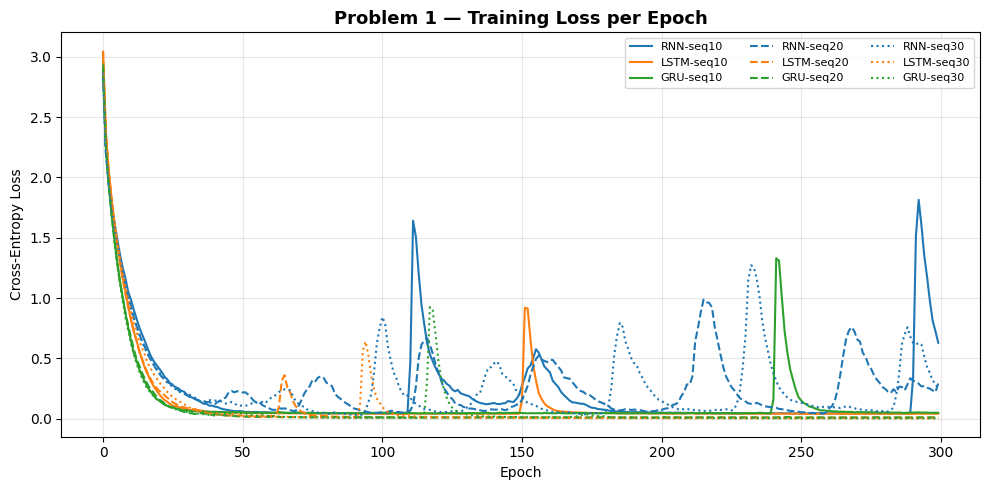

>> Saved: p1_training_loss.png


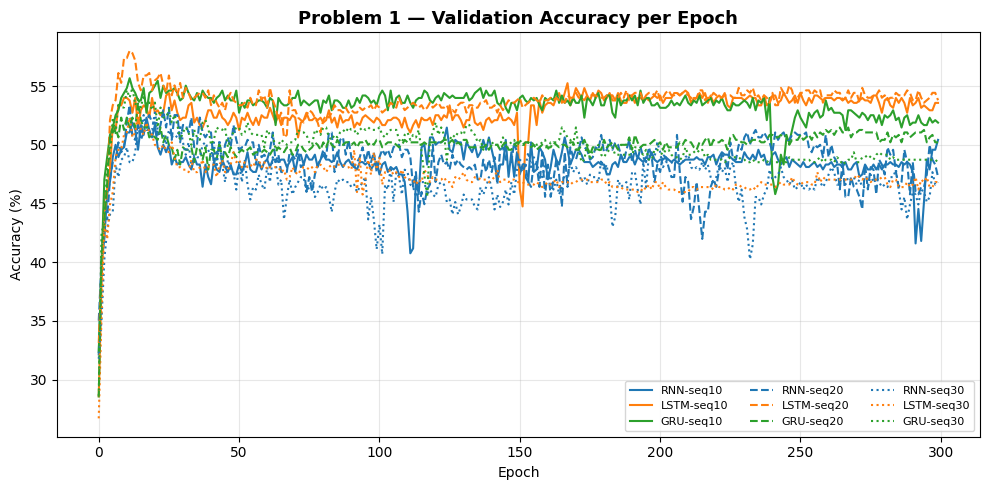

>> Saved: p1_val_accuracy.png


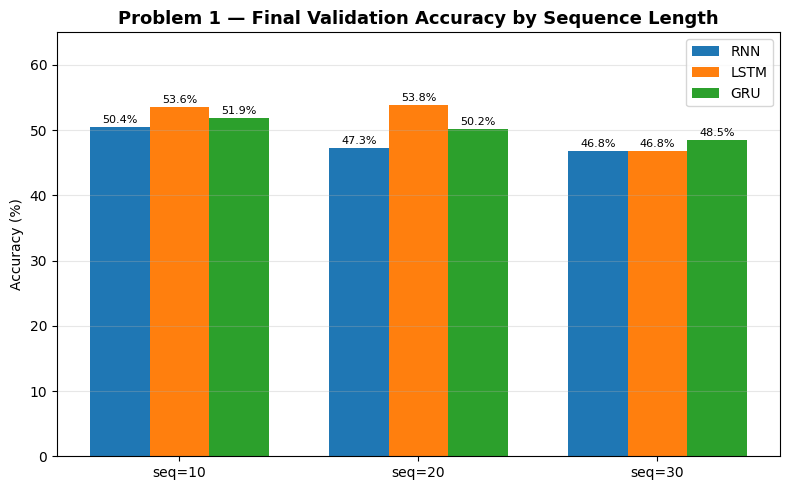

>> Saved: p1_val_accuracy_bar.png


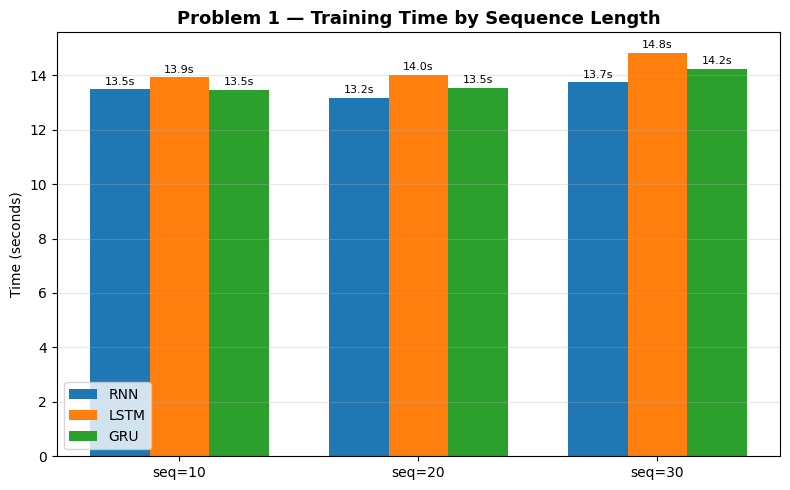

>> Saved: p1_training_time.png


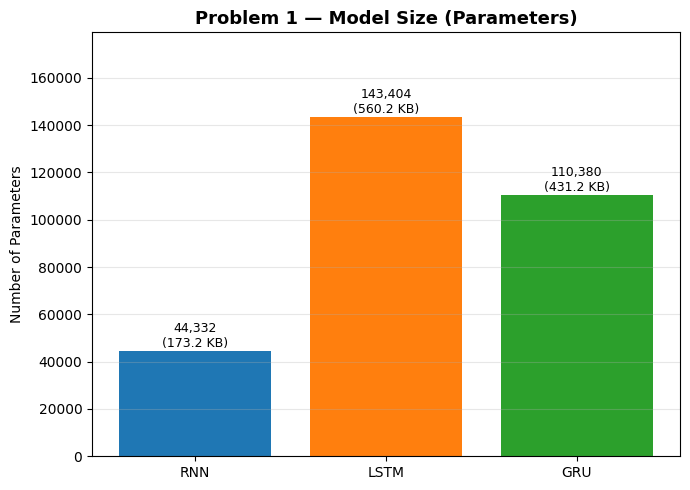

>> Saved: p1_model_size.png

=== Theoretical Complexity (H=hidden=128, E=embed=128, V=vocab, T=seq_len, B=batch) ===

Per-timestep parameter count:
  RNN  : 1 gate  →  H*(H+E)       ≈  128*(128+128) = 32,768
  GRU  : 3 gates →  3*H*(H+E)     ≈  3*128*(256)   = 98,304
  LSTM : 4 gates →  4*H*(H+E)     ≈  4*128*(256)   = 131,072

Per-timestep FLOPs (matrix multiplications dominate):
  RNN  : ~2*H*(H+E)  = ~65,536  FLOPs
  GRU  : ~6*H*(H+E)  = ~196,608 FLOPs
  LSTM : ~8*H*(H+E)  = ~262,144 FLOPs

Total per sequence → multiply above by T (seq_len) and B (batch size)
  Example at seq_len=30, batch=128:
    RNN  : 65,536  × 30 × 128 =  251,658,240  FLOPs
    GRU  : 196,608 × 30 × 128 =  754,974,720  FLOPs
    LSTM : 262,144 × 30 × 128 = 1,006,632,960 FLOPs

FC output head (applied once per sample):
  Parameters : H * V  =  128 * vocab_size
  FLOPs      : 2 * H * V per prediction

Memory at inference (hidden state storage):
  RNN  : O(H)  per layer  — stores h_t only
  GRU  : O(H)  per layer 

In [ ]:
# ── Summary Table ────────────────────────────────────────────────────────────
print("=" * 75)
print("PROBLEM 1 — RESULTS SUMMARY TABLE")
print("=" * 75)
print(f"{'Model':<6} {'SeqLen':>6} {'TrainLoss':>10} {'ValLoss':>9} "
      f"{'ValAcc%':>8} {'Time(s)':>8} {'Params':>10} {'Size(KB)':>9}")
print('-' * 75)
for r in results:
    print(f"{r['model_type']:<6} {r['seq_len']:>6} "
          f"{r['train_losses'][-1]:>10.4f} {r['val_losses'][-1]:>9.4f} "
          f"{r['val_accs'][-1]*100:>8.2f} {r['train_time_s']:>8.1f} "
          f"{r['n_params']:>10,} {r['size_kb']:>9.1f}")

# ── Color / style maps ────────────────────────────────────────────────────────
colors = {'RNN': 'tab:blue', 'LSTM': 'tab:orange', 'GRU': 'tab:green'}
styles = {10: '-', 20: '--', 30: ':'}
MODEL_TYPES = ['RNN', 'LSTM', 'GRU']
SEQ_LENGTHS = [10, 20, 30]

# ═══════════════════════════════════════════════════════
# PLOT 1 — Training Loss
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
for r in results:
    mt, sl = r['model_type'], r['seq_len']
    ax.plot(r['train_losses'],
            color=colors[mt], linestyle=styles[sl],
            label=f"{mt}-seq{sl}")

ax.set_title('Problem 1 — Training Loss per Epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p1_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(">> Saved: p1_training_loss.png")

# ═══════════════════════════════════════════════════════
# PLOT 2 — Validation Accuracy
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
for r in results:
    mt, sl = r['model_type'], r['seq_len']
    ax.plot([v * 100 for v in r['val_accs']],
            color=colors[mt], linestyle=styles[sl],
            label=f"{mt}-seq{sl}")

ax.set_title('Problem 1 — Validation Accuracy per Epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8, ncol=3, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p1_val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(">> Saved: p1_val_accuracy.png")

# ═══════════════════════════════════════════════════════
# PLOT 3 — Final Validation Accuracy Grouped Bar
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
bar_w = 0.25
x = np.arange(len(SEQ_LENGTHS))
for i, mt in enumerate(MODEL_TYPES):
    vals = [r['val_accs'][-1] * 100 for r in results if r['model_type'] == mt]
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=mt, color=colors[mt])
    # Add value labels on top of each bar
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + bar_w)
ax.set_xticklabels([f'seq={s}' for s in SEQ_LENGTHS])
ax.set_title('Problem 1 — Final Validation Accuracy by Sequence Length',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 65)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('p1_val_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(">> Saved: p1_val_accuracy_bar.png")

# ═══════════════════════════════════════════════════════
# PLOT 4 — Training Time Comparison
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
for i, mt in enumerate(MODEL_TYPES):
    vals = [r['train_time_s'] for r in results if r['model_type'] == mt]
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=mt, color=colors[mt])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{v:.1f}s', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + bar_w)
ax.set_xticklabels([f'seq={s}' for s in SEQ_LENGTHS])
ax.set_title('Problem 1 — Training Time by Sequence Length',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Time (seconds)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('p1_training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(">> Saved: p1_training_time.png")

# ═══════════════════════════════════════════════════════
# PLOT 5 — Model Size Comparison
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))
mt_labels = MODEL_TYPES
param_counts = [next(r['n_params'] for r in results if r['model_type'] == mt) for mt in mt_labels]
size_kbs     = [next(r['size_kb']   for r in results if r['model_type'] == mt) for mt in mt_labels]
bar_colors   = [colors[mt] for mt in mt_labels]

bars = ax.bar(mt_labels, param_counts, color=bar_colors)
for bar, p, s in zip(bars, param_counts, size_kbs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{p:,}\n({s:.1f} KB)', ha='center', va='bottom', fontsize=9)

ax.set_title('Problem 1 — Model Size (Parameters)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Parameters')
ax.set_ylim(0, max(param_counts) * 1.25)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('p1_model_size.png', dpi=150, bbox_inches='tight')
plt.show()
print(">> Saved: p1_model_size.png")

# ═══════════════════════════════════════════════════════
# COMPLEXITY ANALYSIS
# ═══════════════════════════════════════════════════════
print("""
=== Theoretical Complexity (H=hidden=128, E=embed=128, V=vocab, T=seq_len, B=batch) ===

Per-timestep parameter count:
  RNN  : 1 gate  →  H*(H+E)       ≈  128*(128+128) = 32,768
  GRU  : 3 gates →  3*H*(H+E)     ≈  3*128*(256)   = 98,304
  LSTM : 4 gates →  4*H*(H+E)     ≈  4*128*(256)   = 131,072

Per-timestep FLOPs (matrix multiplications dominate):
  RNN  : ~2*H*(H+E)  = ~65,536  FLOPs
  GRU  : ~6*H*(H+E)  = ~196,608 FLOPs
  LSTM : ~8*H*(H+E)  = ~262,144 FLOPs

Total per sequence → multiply above by T (seq_len) and B (batch size)
  Example at seq_len=30, batch=128:
    RNN  : 65,536  × 30 × 128 =  251,658,240  FLOPs
    GRU  : 196,608 × 30 × 128 =  754,974,720  FLOPs
    LSTM : 262,144 × 30 × 128 = 1,006,632,960 FLOPs

FC output head (applied once per sample):
  Parameters : H * V  =  128 * vocab_size
  FLOPs      : 2 * H * V per prediction

Memory at inference (hidden state storage):
  RNN  : O(H)  per layer  — stores h_t only
  GRU  : O(H)  per layer  — stores h_t only
  LSTM : O(2H) per layer  — stores both h_t and c_t  (2x RNN/GRU)

Model size (float32 = 4 bytes per parameter):
  size_KB = num_parameters × 4 / 1024
""")

print("Empirical parameter counts (same across all seq_len — architecture only):")
print(f"{'Model':<6} {'Params':>10} {'Size(KB)':>10} {'Relative Size':>14}")
print('-' * 45)
rnn_p = next(r['n_params'] for r in results if r['model_type'] == 'RNN')
for mt in MODEL_TYPES:
    r = next(x for x in results if x['model_type'] == mt and x['seq_len'] == 30)
    ratio = r['n_params'] / rnn_p
    print(f"{mt:<6} {r['n_params']:>10,} {r['size_kb']:>10.1f}   {ratio:>6.1f}x vs RNN")

In [ ]:
@torch.no_grad()
def generate(model, seed_text: str, length: int = 200, temperature: float = 0.8):
    model.eval()
    generated = seed_text
    # Build a rolling window equal to whatever seq_len the model was trained on
    context = [char_to_int.get(c, 0) for c in seed_text]

    for _ in range(length):
        inp    = torch.tensor([context], dtype=torch.long).to(device)  # (1, T)
        logits = model(inp)                                             # (1, vocab_size)
        logits = logits / temperature
        probs  = torch.softmax(logits, dim=-1)
        nxt    = torch.multinomial(probs, 1).item()
        generated += int_to_char[nxt]
        context    = context[1:] + [nxt]   # slide the window forward

    return generated


SEED = 'Next character '   # must be >= seq_len chars; we pad/trim inside if needed
for mtype in MODEL_TYPES:
    # pick the best seq_len=30 model for each type
    best = next(r for r in reversed(results) if r['model_type'] == mtype and r['seq_len'] == 30)
    # seed must be at least seq_len chars long
    seed = (SEED * 4)[:30]
    print(f'\n=== {mtype} (seq_len=30) generated text ===')
    print(generate(best['model'], seed, length=150))


=== RNN (seq_len=30) generated text ===
Next character Next character prediction plary' apareding dicite task LSkk lensed on patbastera laracterss enhused ting human-like text data, allow. These model. One of text during

=== LSTM (seq_len=30) generated text ===
Next character Next character in a characters that precede it. This task is essent relieste be more ef charing the training phased the next character in a follow. These predictions

=== GRU (seq_len=30) generated text ===
Next character Next character prediction paraintain information in 'memore efficient, accurate, and human-like text, as they can mare of text-based to retial data prediction relati


Problem 2

In [ ]:
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
response = requests.get(url)
text = response.text    # full dataset, no slice

# Build vocabulary — identical to Problem 1
chars      = sorted(list(set(text)))
vocab_size = len(chars)
ix_to_char = {i: ch for i, ch in enumerate(chars)}
char_to_ix = {ch: i for i, ch in enumerate(chars)}

# Encode the full text into integers
encoded_text = [char_to_ix[ch] for ch in text]

print(f'Text length : {len(text):,} characters')
print(f'Vocabulary  : {vocab_size} unique characters')
print(f'Sample      : {text[:100]}')

class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets   = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]


def make_loaders(sequence_length, batch_size=128):
    sequences, targets = [], []
    for i in range(len(encoded_text) - sequence_length):
        seq    = encoded_text[i : i + sequence_length]
        target = encoded_text[i + sequence_length]
        sequences.append(seq)
        targets.append(target)

    sequences = torch.tensor(sequences, dtype=torch.long)
    targets   = torch.tensor(targets,   dtype=torch.long)

    dataset    = CharDataset(sequences, targets)
    train_size = int(len(dataset) * 0.8)
    test_size  = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, test_size]
    )
    train_loader = DataLoader(train_dataset, shuffle=True,  batch_size=batch_size)
    test_loader  = DataLoader(test_dataset,  shuffle=False, batch_size=batch_size)
    return train_loader, test_loader

print('Dataset class and loader ready.')

# ── LSTM Model ──────────────────────────────────────────────────────────────
class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(CharLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(input_size, hidden_size)
        self.rnn         = nn.LSTM(hidden_size, hidden_size,
                                   num_layers=num_layers, batch_first=True)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded    = self.embedding(x)
        output, _   = self.rnn(embedded)
        output      = self.fc(output[:, -1, :])   # last timestep only
        return output


# ── GRU Model ───────────────────────────────────────────────────────────────
class CharGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(CharGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(input_size, hidden_size)
        self.rnn         = nn.GRU(hidden_size, hidden_size,
                                  num_layers=num_layers, batch_first=True)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded    = self.embedding(x)
        output, _   = self.rnn(embedded)
        output      = self.fc(output[:, -1, :])   # last timestep only
        return output


# ── LSTM with deeper FC head (used in Part 2 FC sweep) ──────────────────────
class CharLSTM_DeepFC(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, fc_layers=2):
        super(CharLSTM_DeepFC, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(input_size, hidden_size)
        self.rnn         = nn.LSTM(hidden_size, hidden_size,
                                   num_layers=num_layers, batch_first=True)
        # Extra FC layers before the final output projection
        self.fc_hidden   = nn.Linear(hidden_size, hidden_size)
        self.relu        = nn.ReLU()
        self.fc_out      = nn.Linear(hidden_size, output_size)
        self.fc_layers   = fc_layers

    def forward(self, x):
        embedded  = self.embedding(x)
        output, _ = self.rnn(embedded)
        output    = output[:, -1, :]              # last timestep
        for _ in range(self.fc_layers - 1):       # extra hidden FC passes
            output = self.relu(self.fc_hidden(output))
        output    = self.fc_out(output)
        return output


# ── GRU with deeper FC head ──────────────────────────────────────────────────
class CharGRU_DeepFC(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, fc_layers=2):
        super(CharGRU_DeepFC, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(input_size, hidden_size)
        self.rnn         = nn.GRU(hidden_size, hidden_size,
                                  num_layers=num_layers, batch_first=True)
        self.fc_hidden   = nn.Linear(hidden_size, hidden_size)
        self.relu        = nn.ReLU()
        self.fc_out      = nn.Linear(hidden_size, output_size)
        self.fc_layers   = fc_layers

    def forward(self, x):
        embedded  = self.embedding(x)
        output, _ = self.rnn(embedded)
        output    = output[:, -1, :]
        for _ in range(self.fc_layers - 1):
            output = self.relu(self.fc_hidden(output))
        output    = self.fc_out(output)
        return output


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_kb(model):
    return count_parameters(model) * 4 / 1024

print('CharLSTM, CharGRU, CharLSTM_DeepFC, CharGRU_DeepFC defined.')

Text length : 1,115,394 characters
Vocabulary  : 65 unique characters
Sample      : First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You
Dataset class and loader ready.
CharLSTM, CharGRU, CharLSTM_DeepFC, CharGRU_DeepFC defined.


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss   = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            output = model(x)
            loss   = criterion(output, y)
            total_loss += loss.item()
            _, predicted = torch.max(output, 1)
            correct     += (predicted == y).sum().item()
            total       += y.size(0)
    return total_loss / len(loader), correct / total

# changed learning rate from 0.005 to 0.001 and rerunning
def train_model(model, model_name, seq_len, epochs=10, lr=0.001, batch_size=128):
    print(f'\n=== {model_name} | seq_len={seq_len} ===')

    train_loader, test_loader = make_loaders(seq_len, batch_size)
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, val_accs = [], [], []

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss       = train_epoch(model, train_loader, optimizer, criterion)
        v_loss, v_acc = evaluate(model, test_loader, criterion)
        train_losses.append(tr_loss)
        val_losses.append(v_loss)
        val_accs.append(v_acc)
        print(f'Epoch {epoch}, Loss: {tr_loss:.4f}, '
                  f'Validation Loss: {v_loss:.4f}, '
                  f'Validation Accuracy: {v_acc:.4f}')
    elapsed = time.time() - t0

    n_params = count_parameters(model)
    size_kb  = model_size_kb(model)
    print(f'Time: {elapsed:.1f}s | Params: {n_params:,} | Size: {size_kb:.1f} KB')

    return {
        'model_name'   : model_name,
        'seq_len'      : seq_len,
        'train_losses' : train_losses,
        'val_losses'   : val_losses,
        'val_accs'     : val_accs,
        'train_time_s' : elapsed,
        'n_params'     : n_params,
        'size_kb'      : size_kb,
        'model'        : model,
    }

print('Training functions ready.')

Training functions ready.


In [ ]:
hidden_size = 128
part1_results = []

# LSTM seq_len=20
model = CharLSTM(vocab_size, hidden_size, vocab_size)
part1_results.append(train_model(model, 'LSTM', seq_len=20))

# GRU seq_len=20
model = CharGRU(vocab_size, hidden_size, vocab_size)
part1_results.append(train_model(model, 'GRU', seq_len=20))

# LSTM seq_len=30
model = CharLSTM(vocab_size, hidden_size, vocab_size)
part1_results.append(train_model(model, 'LSTM', seq_len=30))

# GRU seq_len=30
model = CharGRU(vocab_size, hidden_size, vocab_size)
part1_results.append(train_model(model, 'GRU', seq_len=30))

print('\nPart 1 complete.')


=== LSTM | seq_len=20 ===
Epoch 1, Loss: 1.8110, Validation Loss: 1.5842, Validation Accuracy: 0.5237
Epoch 2, Loss: 1.5203, Validation Loss: 1.4869, Validation Accuracy: 0.5464
Epoch 3, Loss: 1.4491, Validation Loss: 1.4432, Validation Accuracy: 0.5587
Epoch 4, Loss: 1.4090, Validation Loss: 1.4241, Validation Accuracy: 0.5619
Epoch 5, Loss: 1.3822, Validation Loss: 1.4063, Validation Accuracy: 0.5663
Epoch 6, Loss: 1.3625, Validation Loss: 1.3946, Validation Accuracy: 0.5692
Epoch 7, Loss: 1.3460, Validation Loss: 1.3885, Validation Accuracy: 0.5710
Epoch 8, Loss: 1.3333, Validation Loss: 1.3779, Validation Accuracy: 0.5741
Epoch 9, Loss: 1.3219, Validation Loss: 1.3695, Validation Accuracy: 0.5757
Epoch 10, Loss: 1.3123, Validation Loss: 1.3702, Validation Accuracy: 0.5765
Time: 252.1s | Params: 280,897 | Size: 1097.3 KB

=== GRU | seq_len=20 ===
Epoch 1, Loss: 1.7269, Validation Loss: 1.5439, Validation Accuracy: 0.5331
Epoch 2, Loss: 1.4870, Validation Loss: 1.4743, Validation Ac

Model   SeqLen  TrainLoss   ValLoss  ValAcc%  Time(s)     Params      KB
----------------------------------------------------------------------
LSTM        20     1.3123    1.3702    57.65    252.1    280,897  1097.3
GRU         20     1.3510    1.4022    56.99    237.4    214,849   839.3
LSTM        30     1.2988    1.3575    58.26    266.1    280,897  1097.3
GRU         30     1.3332    1.3806    57.59    251.8    214,849   839.3


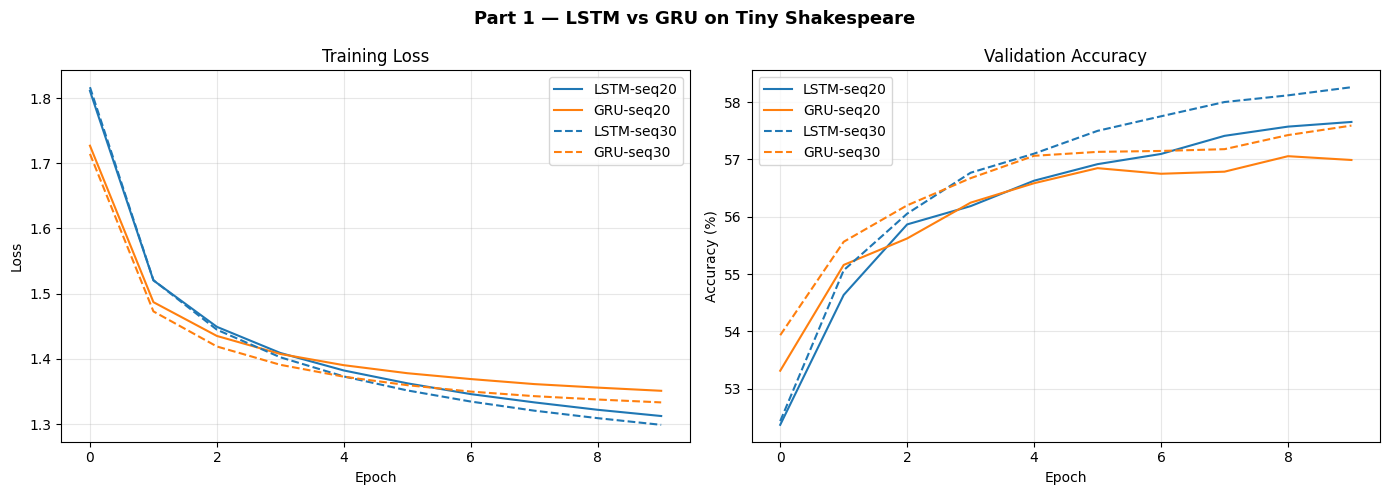

In [ ]:
# Part 1 Summary Table
print(f"{'Model':<6} {'SeqLen':>7} {'TrainLoss':>10} {'ValLoss':>9} {'ValAcc%':>8} {'Time(s)':>8} {'Params':>10} {'KB':>7}")
print('-' * 70)
for r in part1_results:
    print(f"{r['model_name']:<6} {r['seq_len']:>7} "
          f"{r['train_losses'][-1]:>10.4f} {r['val_losses'][-1]:>9.4f} "
          f"{r['val_accs'][-1]*100:>8.2f} {r['train_time_s']:>8.1f} "
          f"{r['n_params']:>10,} {r['size_kb']:>7.1f}")
  # Part 1 Plots
colors  = {'LSTM': 'tab:blue', 'GRU': 'tab:orange'}
lstyles = {20: '-', 30: '--'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part 1 — LSTM vs GRU on Tiny Shakespeare', fontsize=13, fontweight='bold')

for r in part1_results:
    mn, sl = r['model_name'], r['seq_len']
    lbl = f"{mn}-seq{sl}"
    axes[0].plot(r['train_losses'],              color=colors[mn], linestyle=lstyles[sl], label=lbl)
    axes[1].plot([v*100 for v in r['val_accs']], color=colors[mn], linestyle=lstyles[sl], label=lbl)

axes[0].set_title('Training Loss');       axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('p2_part1.png', dpi=150, bbox_inches='tight')
plt.show()


=== LSTM-H64 | seq_len=30 ===
Epoch 1, Loss: 2.0166, Validation Loss: 1.7609, Validation Accuracy: 0.4843
Epoch 2, Loss: 1.6826, Validation Loss: 1.6414, Validation Accuracy: 0.5119
Epoch 3, Loss: 1.5998, Validation Loss: 1.5890, Validation Accuracy: 0.5243
Epoch 4, Loss: 1.5531, Validation Loss: 1.5565, Validation Accuracy: 0.5327
Epoch 5, Loss: 1.5218, Validation Loss: 1.5271, Validation Accuracy: 0.5400
Epoch 6, Loss: 1.4987, Validation Loss: 1.5149, Validation Accuracy: 0.5436
Epoch 7, Loss: 1.4803, Validation Loss: 1.4969, Validation Accuracy: 0.5470
Epoch 8, Loss: 1.4660, Validation Loss: 1.4854, Validation Accuracy: 0.5507
Epoch 9, Loss: 1.4542, Validation Loss: 1.4792, Validation Accuracy: 0.5526
Epoch 10, Loss: 1.4440, Validation Loss: 1.4720, Validation Accuracy: 0.5537
Time: 261.0s | Params: 74,945 | Size: 292.8 KB

=== GRU-H64 | seq_len=30 ===
Epoch 1, Loss: 1.8959, Validation Loss: 1.6811, Validation Accuracy: 0.5044
Epoch 2, Loss: 1.6168, Validation Loss: 1.5890, Validat

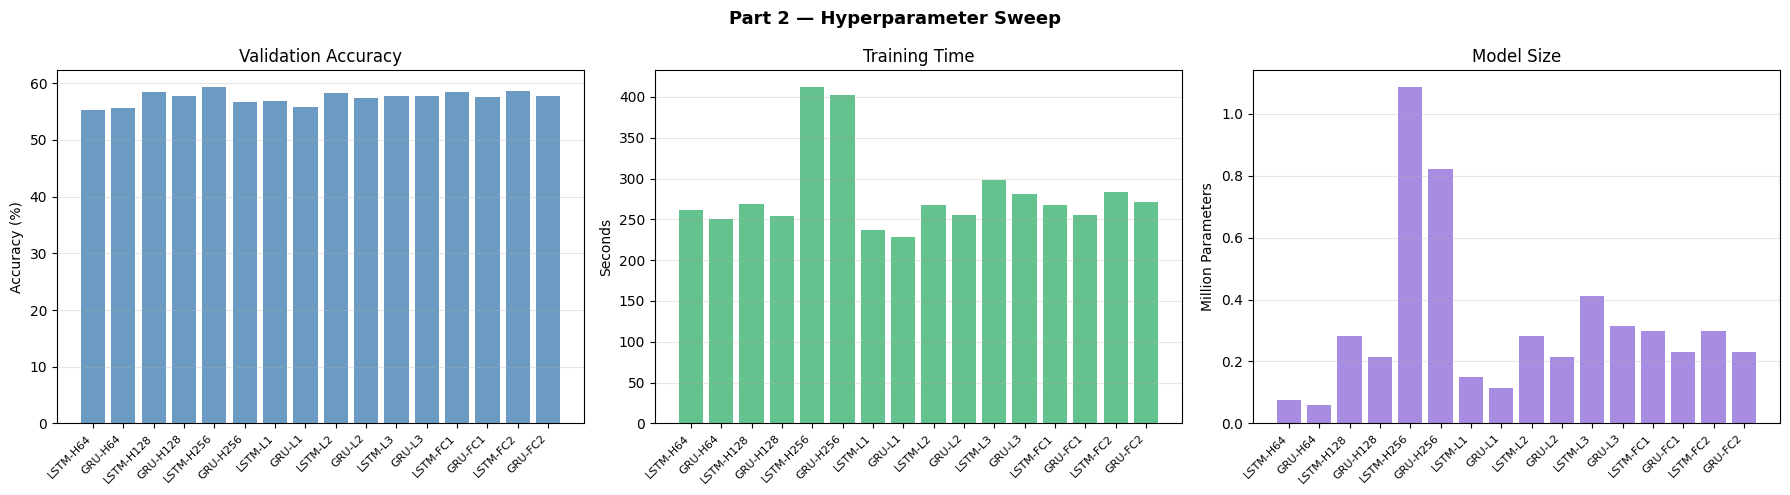

In [ ]:
part2_results = []

# ── Vary hidden size ─────────────────────────────────────────────────────────
#
for h in [64, 128, 256]:
    model = CharLSTM(vocab_size, h, vocab_size)
    part2_results.append(train_model(model, f'LSTM-H{h}', seq_len=30))

    model = CharGRU(vocab_size, h, vocab_size)
    part2_results.append(train_model(model, f'GRU-H{h}', seq_len=30))


# ── Vary number of RNN layers ────────────────────────────────────────────────
for l in [1, 2, 3]:
    model = CharLSTM(vocab_size, 128, vocab_size, num_layers=l)
    part2_results.append(train_model(model, f'LSTM-L{l}', seq_len=30))

    model = CharGRU(vocab_size, 128, vocab_size, num_layers=l)
    part2_results.append(train_model(model, f'GRU-L{l}', seq_len=30))

# ── Vary FC depth ────────────────────────────────────────────────────────────
for fc in [1, 2]:
    model = CharLSTM_DeepFC(vocab_size, 128, vocab_size, fc_layers=fc)
    part2_results.append(train_model(model, f'LSTM-FC{fc}', seq_len=30))

    model = CharGRU_DeepFC(vocab_size, 128, vocab_size, fc_layers=fc)
    part2_results.append(train_model(model, f'GRU-FC{fc}', seq_len=30))

print('\nPart 2 complete.')

import math

# After part2_results is complete, print the full table
print(f"{'Model':<12} {'ValAcc%':>8} {'PPL':>7} {'Time(s)':>8} {'Params':>10} {'KB':>7}")
print('-' * 55)
for r in part2_results:
    ppl = math.exp(r['val_losses'][-1])   # perplexity = exp(val_loss)
    print(f"{r['model_name']:<12} "
          f"{r['val_accs'][-1]*100:>8.2f} "
          f"{ppl:>7.2f} "
          f"{r['train_time_s']:>8.1f} "
          f"{r['n_params']:>10,} "
          f"{r['size_kb']:>7.1f}")

def inference_time(model, seq_len, n_runs=100):
    model.eval()
    x = torch.randint(0, vocab_size, (1, seq_len)).to(device)
    with torch.no_grad():
        t0 = time.time()
        for _ in range(n_runs):
            model(x)
    return (time.time() - t0) / n_runs * 1000   # milliseconds

print(f"{'Model':<12} {'Infer(ms)':>10}")
print('-' * 25)
for r in part2_results:
    ms = inference_time(r['model'], seq_len=30)
    print(f"{r['model_name']:<12} {ms:>10.3f}")

# Part 2 Bar Charts
labels = [r['model_name'] for r in part2_results]
accs   = [r['val_accs'][-1]*100   for r in part2_results]
times  = [r['train_time_s']       for r in part2_results]
params = [r['n_params'] / 1e6     for r in part2_results]
x      = np.arange(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 2 — Hyperparameter Sweep', fontsize=13, fontweight='bold')

for ax, vals, title, ylabel, color in zip(
    axes,
    [accs, times, params],
    ['Validation Accuracy', 'Training Time', 'Model Size'],
    ['Accuracy (%)', 'Seconds', 'Million Parameters'],
    ['steelblue', 'mediumseagreen', 'mediumpurple']
):
    ax.bar(x, vals, color=color, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('p2_part2.png', dpi=150, bbox_inches='tight')
plt.show()


=== LSTM | seq_len=50 ===
Epoch 1, Loss: 1.7953, Validation Loss: 1.5648, Validation Accuracy: 0.5305
Epoch 2, Loss: 1.4994, Validation Loss: 1.4696, Validation Accuracy: 0.5524
Epoch 3, Loss: 1.4270, Validation Loss: 1.4257, Validation Accuracy: 0.5656
Epoch 4, Loss: 1.3855, Validation Loss: 1.4016, Validation Accuracy: 0.5700
Epoch 5, Loss: 1.3570, Validation Loss: 1.3840, Validation Accuracy: 0.5756
Epoch 6, Loss: 1.3357, Validation Loss: 1.3741, Validation Accuracy: 0.5793
Epoch 7, Loss: 1.3187, Validation Loss: 1.3632, Validation Accuracy: 0.5819
Epoch 8, Loss: 1.3045, Validation Loss: 1.3534, Validation Accuracy: 0.5850
Epoch 9, Loss: 1.2926, Validation Loss: 1.3530, Validation Accuracy: 0.5857
Epoch 10, Loss: 1.2823, Validation Loss: 1.3440, Validation Accuracy: 0.5868
Time: 271.8s | Params: 280,897 | Size: 1097.3 KB

=== GRU | seq_len=50 ===
Epoch 1, Loss: 1.7147, Validation Loss: 1.5252, Validation Accuracy: 0.5412
Epoch 2, Loss: 1.4730, Validation Loss: 1.4574, Validation Ac

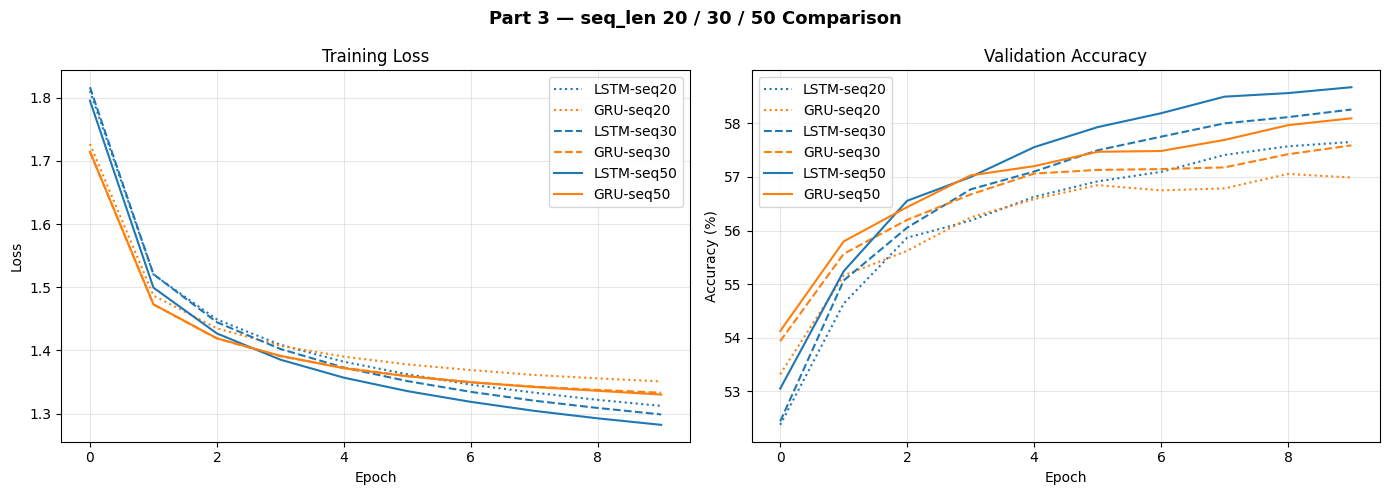

In [ ]:
part3_results = []

model = CharLSTM(vocab_size, hidden_size, vocab_size)
part3_results.append(train_model(model, 'LSTM', seq_len=50))

model = CharGRU(vocab_size, hidden_size, vocab_size)
part3_results.append(train_model(model, 'GRU', seq_len=50))

print('\nPart 3 complete.')
# Compare seq_len 20, 30, 50 side by side
all_results = part1_results + part3_results

print(f"{'Model':<6} {'SeqLen':>7} {'ValAcc%':>8} {'TrainLoss':>10} {'ValLoss':>9} {'Time(s)':>8} {'Params':>10}")
print('-' * 65)
for r in all_results:
    print(f"{r['model_name']:<6} {r['seq_len']:>7} "
          f"{r['val_accs'][-1]*100:>8.2f} "
          f"{r['train_losses'][-1]:>10.4f} "
          f"{r['val_losses'][-1]:>9.4f} "
          f"{r['train_time_s']:>8.1f} "
          f"{r['n_params']:>10,}")

# Plot all seq lengths together
colors  = {'LSTM': 'tab:blue', 'GRU': 'tab:orange'}
lstyles = {20: ':', 30: '--', 50: '-'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part 3 — seq_len 20 / 30 / 50 Comparison', fontsize=13, fontweight='bold')

for r in all_results:
    mn, sl = r['model_name'], r['seq_len']
    lbl = f"{mn}-seq{sl}"
    axes[0].plot(r['train_losses'],              color=colors[mn], linestyle=lstyles[sl], label=lbl)
    axes[1].plot([v*100 for v in r['val_accs']], color=colors[mn], linestyle=lstyles[sl], label=lbl)

axes[0].set_title('Training Loss');       axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('p2_part3.png', dpi=150, bbox_inches='tight')
plt.show()